### Aligning the mirrors M1 and M2 after the SLM

Because the beam falling on the SLM is ~9.6 to 9.7 mm in diameter, it s hard to resolve the 1st order from the specularly reflected 0th order.

Hence, I will separte the SLM sensor into two parts, a central part of dia 1-2 mm that will give the required 1st order carrier and the rest of the SLM sensor will have another phase that could be either all 0 (cpnstant phase) or a dumper blaze.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats


# Plotting
set_matplotlib_formats("retina")

plt.style.use(
    "https://raw.githubusercontent.com/"
    "ksingh1121/python-plot-style/main/physics.mplstyle"
)


from slmsuite.hardware.slms.meadowlark import Meadowlark

In [2]:
# ============================================================
# Meadowlark paths
# ============================================================

SDK_PATH = Path(
    r"C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\SDK"
)

LUT_PATH = Path(
    r"C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\Experiment scripts"
    r"\LUT_locked_759nm_20260811_201109\759nm_KS_global_20260811.lut"
)


print("SDK exists :", SDK_PATH.exists())
print("LUT exists :", LUT_PATH.exists())


# ============================================================
# Initialize SLM
# ============================================================

slm = Meadowlark(
    slm_number=1,
    sdk_path=str(SDK_PATH),
    lut_path=str(LUT_PATH),
    wav_um=0.759,
    verbose=True,
)


print("\n=== SLM READY ===")
print("Name       :", slm.name)
print("Shape      :", slm.shape)
print("Wavelength :", slm.wav_um, "um")
print("Pixel pitch:", slm.pitch_um, "um")

SDK exists : True
LUT exists : True
Validating DPI awareness...success
Constructing Blink SDK...success
Loading LUT file...
=== SLM READY ===
Name       : Meadowlark HDMI
Shape      : (1200, 1920)
Wavelength : 0.759 um
Pixel pitch: [8. 8.] um


### Simple zero phase to the entire SLM to spot the zeroth

In [3]:
slm.set_phase(None, settle=True)

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]],
      shape=(1200, 1920), dtype=uint8)

### Simple blaze to see if the SLM is responding

Sometimes the SLM can fuck up due to multiple reasons so it is better to check if your call is really doing something to the SLM.

In order to do this I check if a simple 1D blaze can be written on it!

In [4]:
import numpy as np
from slmsuite.holography.toolbox import convert_vector
from slmsuite.holography.toolbox.phase import blaze

vec = convert_vector(
    (10.0, 0.0),
    from_units="mrad",
    to_units="kxy",
    hardware=slm,
)

phase = blaze(
    grid=slm,
    vector=tuple(np.ravel(vec)),
)

slm.set_phase(phase, settle=True)

array([[ 33,   6, 235, ...,  19, 248, 221],
       [ 33,   6, 235, ...,  19, 248, 221],
       [ 33,   6, 235, ...,  19, 248, 221],
       ...,
       [ 33,   6, 235, ...,  19, 248, 221],
       [ 33,   6, 235, ...,  19, 248, 221],
       [ 33,   6, 235, ...,  19, 248, 221]],
      shape=(1200, 1920), dtype=uint8)

### Small alignment beam

Now as a next step I will just see if the central thing blaze and the exterior dump blaze generates the required pattern. Just on the python side.

Then as a next step I will write this on the SLM.

=== Alignment mask ===
SLM shape              : (1200, 1920)
Patch diameter         : 2 mm
Patch diameter         : 250.0 pixels
Useful carrier period  : 16 pixels
Dump period            : 3 pixels
Phase range            : 0.1963495408493614 to 6.086835766330225 rad


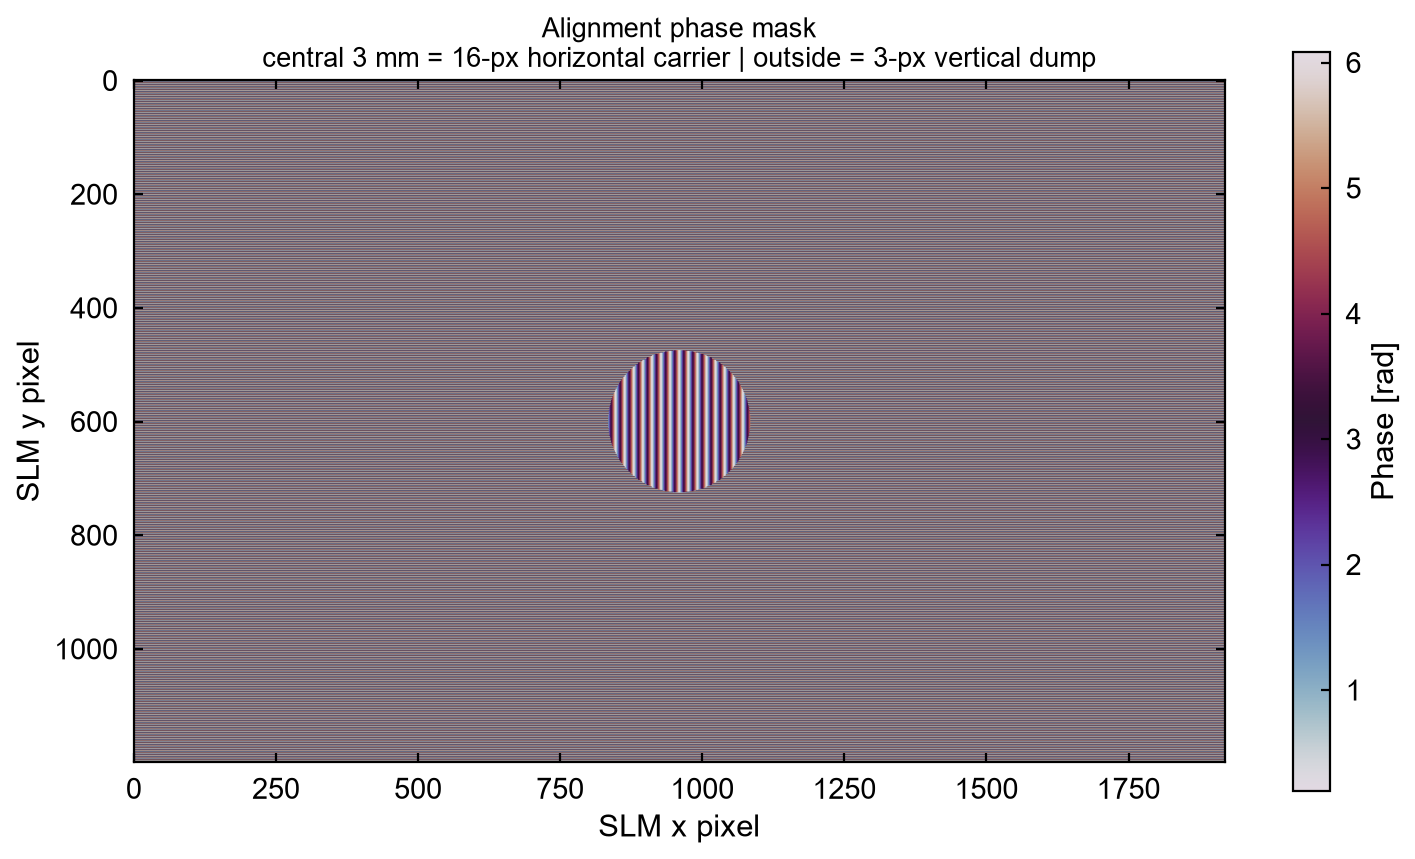

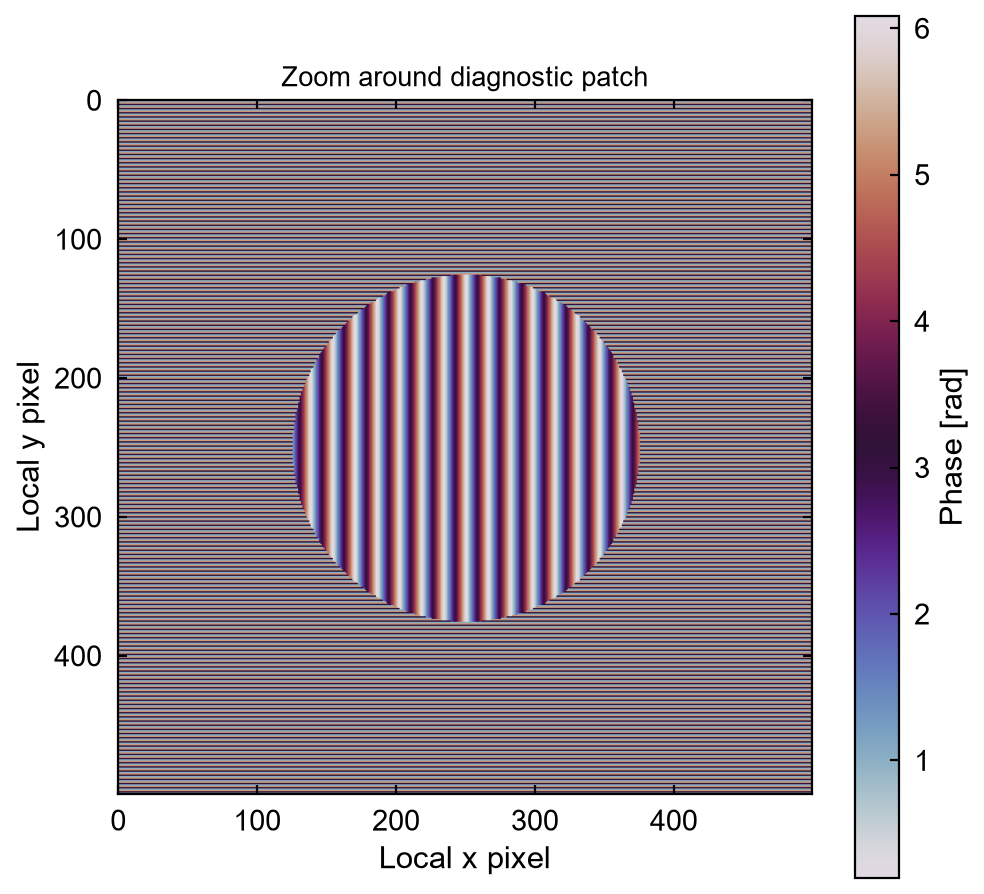

In [ ]:
# ============================================================
# Diagnostic carrier pattern
# NO HARDWARE WRITE IN THIS CELL
# ============================================================

ny, nx = slm.shape
pixel_um = 8.0

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

PATCH_DIAMETER_MM = 1.5       # diagnostic patch diameter

CARRIER_PERIOD_PX = 16       # permanent useful carrier
DUMP_PERIOD_PX = 3           # temporary dump for rest of beam

# SLM center
cx = (nx - 1) / 2
cy = (ny - 1) / 2


# ============================================================
# Pixel coordinate arrays
# ============================================================

yy, xx = np.indices((ny, nx))

x = xx - cx
y = yy - cy


# ============================================================
# Circular diagnostic patch
# ============================================================

patch_radius_px = (
    PATCH_DIAMETER_MM * 1000
    / (2 * pixel_um)
)

patch_mask = (
    x**2 + y**2 <= patch_radius_px**2
)


# ============================================================
# Useful carrier:
# 16-pixel horizontal blaze
# ============================================================

phase_carrier = (
    2 * np.pi * x / CARRIER_PERIOD_PX
)


# ============================================================
# Dump carrier:
# 3-pixel vertical blaze
# ============================================================

phase_dump = (
    -2 * np.pi * y / DUMP_PERIOD_PX
)


# ============================================================
# Combine
# ============================================================

phase_alignment = np.where(
    patch_mask,
    phase_carrier,
    phase_dump,
)

# Wrap into [0, 2pi)
phase_alignment = np.mod(
    phase_alignment,
    2 * np.pi,
)


# ============================================================
# Information
# ============================================================

print("=== Alignment mask ===")
print("SLM shape              :", phase_alignment.shape)
print("Patch diameter         :", PATCH_DIAMETER_MM, "mm")
print("Patch diameter         :", 2 * patch_radius_px, "pixels")
print("Useful carrier period  :", CARRIER_PERIOD_PX, "pixels")
print("Dump period            :", DUMP_PERIOD_PX, "pixels")
print("Phase range            :",
      phase_alignment.min(),
      "to",
      phase_alignment.max(),
      "rad")


# ============================================================
# Plot full SLM
# ============================================================

plt.figure(figsize=(11, 6))

plt.imshow(
    phase_alignment,
    origin="upper",
    cmap="twilight",
)

plt.colorbar(label="Phase [rad]")

plt.title(
    "Alignment phase mask\n"
    "central 3 mm = 16-px horizontal carrier | "
    "outside = 3-px vertical dump"
)

plt.xlabel("SLM x pixel")
plt.ylabel("SLM y pixel")

plt.show()


# ============================================================
# Zoom into central region
# ============================================================

zoom = 250

plt.figure(figsize=(7, 7))

plt.imshow(
    phase_alignment[
        int(cy - zoom):int(cy + zoom),
        int(cx - zoom):int(cx + zoom)
    ],
    origin="upper",
    cmap="twilight",
)

plt.colorbar(label="Phase [rad]")

plt.title("Zoom around diagnostic patch")

plt.xlabel("Local x pixel")
plt.ylabel("Local y pixel")

plt.show()

In [8]:
print("Writing diagnostic alignment mask to SLM...")

slm.set_phase(
    phase_alignment,
    settle=True,
)

print("Done.")

Writing diagnostic alignment mask to SLM...
Done.


In [52]:
# ============================================================
# FULL-SLM 16-pixel carrier
# Same direction as the pilot beam
# ============================================================

CARRIER_PERIOD_PX = 16

phase_full_carrier = (
    2 * np.pi * x / CARRIER_PERIOD_PX
)

phase_full_carrier = np.mod(
    phase_full_carrier,
    2 * np.pi
)

# Write to SLM
slm.set_phase(
    phase_full_carrier,
    settle=True,
)

print("Full-aperture 16-pixel carrier written.")

Full-aperture 16-pixel carrier written.
